In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap


# Task 1: Data Preparation

# Load dataset (assuming first column is an index based on the snippet)
df = pd.read_csv('brca.csv', index_col=0)

# Explore structure
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum().max()) # Check max missing across columns
print("Duplicates:", df.duplicated().sum())

# Drop duplicates/missing if any exist
df = df.dropna().drop_duplicates()

# Map target variable 'y' to binary (M = 1, B = 0)
df['y'] = df['y'].map({'M': 1, 'B': 0})

# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)








Dataset Shape: (569, 31)

Missing Values:
 0
Duplicates: 0


Task 1: Feature Scaling Justification
Feature scaling is required because KNN is a distance-based algorithm. If one feature (e.g., area_mean in the hundreds) has a much larger scale than another (e.g., smoothness_mean in decimals), the larger feature will disproportionately dominate the distance calculation. StandardScaler ensures all features contribute equally by transforming them to have a mean of 0 and standard deviation of 1.

In [2]:

# Task 2: Train-Test Split Analysis

splits = [(0.2, "80:20"), (0.3, "70:30"), (0.1, "90:10")]
split_results = {}

for test_sz, label in splits:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_sz, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5) # arbitrary baseline for split test
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    split_results[label] = acc
    print(f"Accuracy for {label} split: {acc:.4f}")

Accuracy for 80:20 split: 0.9298
Accuracy for 70:30 split: 0.9591
Accuracy for 90:10 split: 0.9298



Heuristic Baseline K: 21


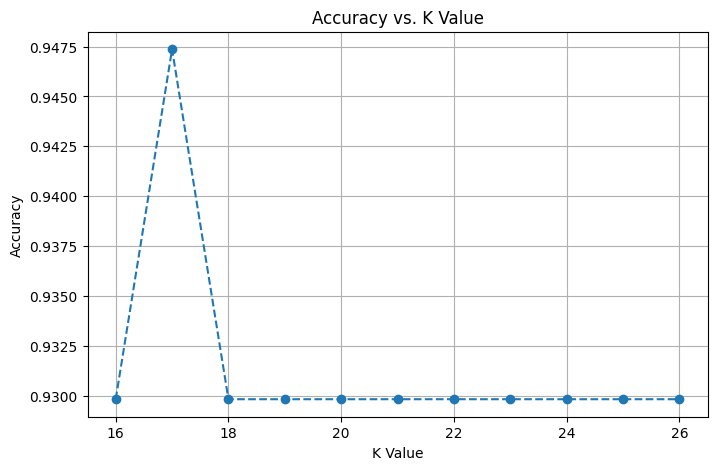

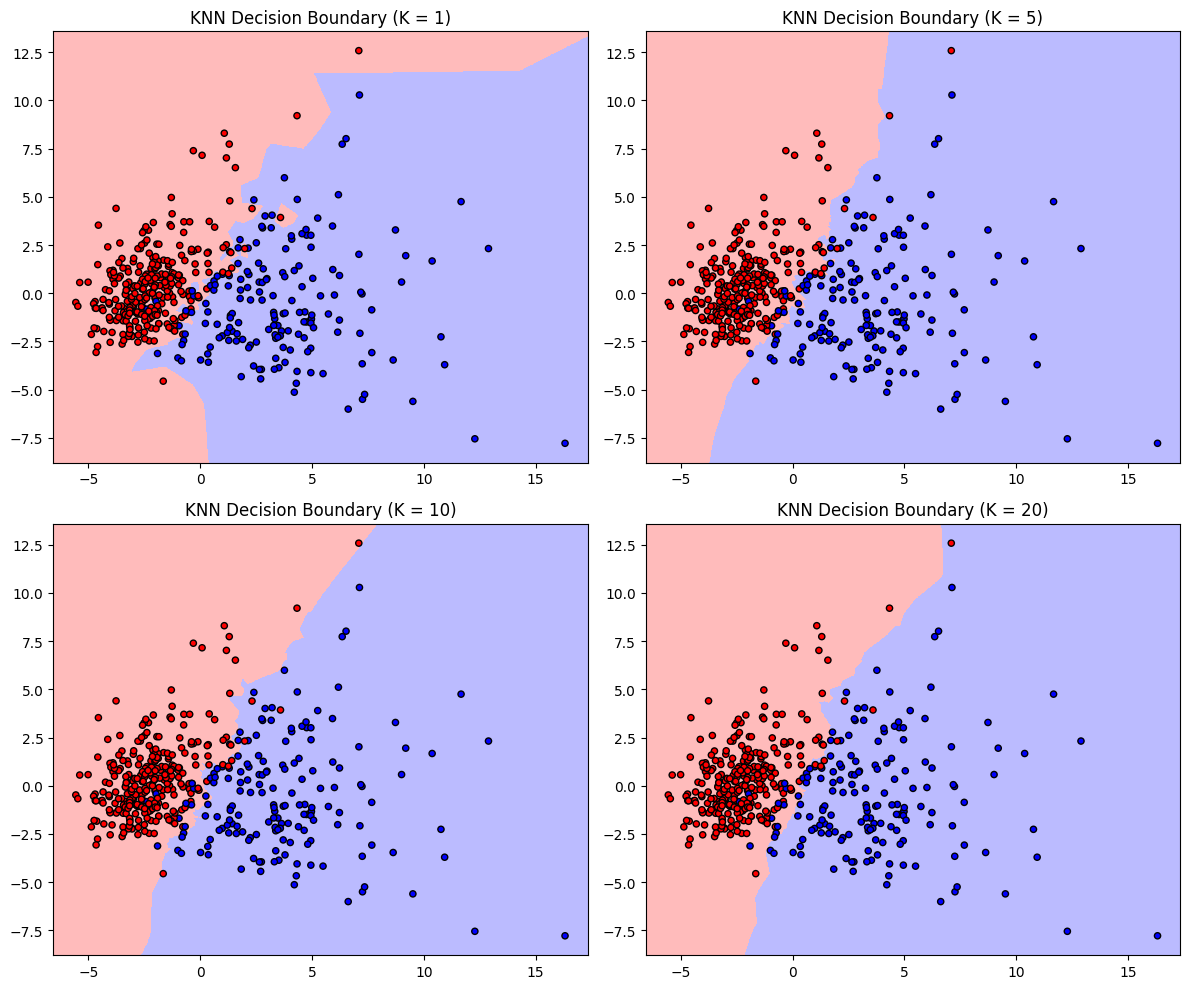

In [3]:


# Task 3: KNN Model with Heuristic K Selection

# 3.1 Heuristic Method
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
n_samples = X_train.shape[0]
heuristic_k = int(np.sqrt(n_samples))
if heuristic_k % 2 == 0: heuristic_k += 1  # Make it odd to avoid ties
print(f"\nHeuristic Baseline K: {heuristic_k}")

# 3.2 Model Training (K +/- 5)
k_values = range(max(1, heuristic_k - 5), heuristic_k + 6)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed')
plt.title('Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# 3.3 Decision Boundary Mapping (Using PCA to reduce to 2D for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

def plot_decision_boundary(X, y, k_list):
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])
    h = .02  # step size in the mesh
    
    plt.figure(figsize=(12, 10))
    for i, k in enumerate(k_list, 1):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X, y)
        
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        plt.subplot(2, 2, i)
        plt.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=0.8)
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
        plt.title(f"KNN Decision Boundary (K = {k})")
    plt.tight_layout()
    plt.show()

plot_decision_boundary(X_train_pca, y_train_pca, [1, 5, 10, 20])

Task 3.3: Distance Metrics and Decision BoundariesEuclidean Distance: Measures the straight-line distance between two points. It is best used for continuous numerical data where relationships between features are roughly isotropic (spherical).

Manhattan Distance: Measures the distance by only moving along orthogonal axes (like navigating city blocks). It is highly suitable for high-dimensional data or when the dataset contains distinct outliers, as it does not square the differences.

Decision Boundary Analysis: * $K = 1$: The boundary is highly fragmented and captures noise (overfitting).$K = 20$: The boundary is smooth and generalized. As $K$ increases, the model relies on broader regional majorities, reducing variance but potentially increasing bias (underfitting).

In [4]:

# Task 4: Cross Validation

cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"\nOptimal K based on 5-Fold CV: {optimal_k}")


Optimal K based on 5-Fold CV: 17



--- Final Model Evaluation ---
Accuracy: 0.9474
Precision: 1.0000
Recall: 0.8605
F1 Score: 0.9250


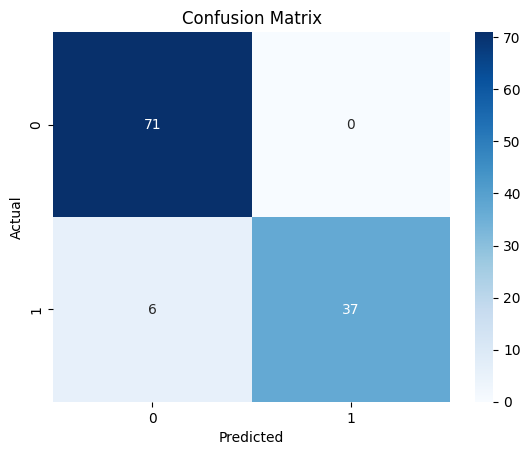

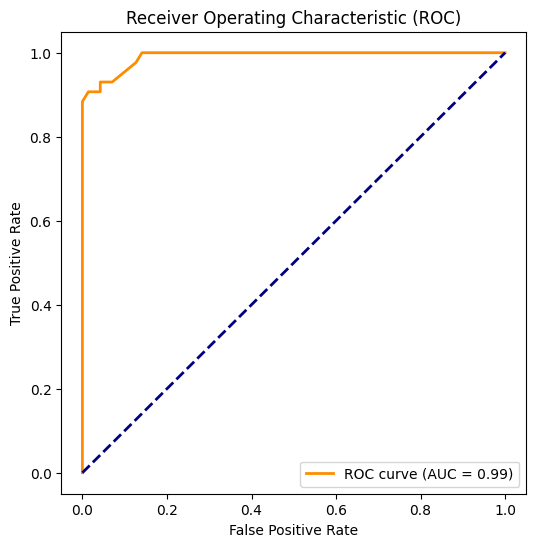

In [5]:

# Task 5: Classification Evaluation

final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)
y_prob = final_knn.predict_proba(X_test)[:, 1]

print("\n--- Final Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

Task 6: Comparative Study with Regression

Error-Based vs. Decision-Based Evaluation:
    Regression (Error-Based): 
    Models continuous targets. Metrics evaluate the magnitude of the mistake. If a house is predicted to cost $50,000 instead of $52,000, the model is penalized for the numerical distance of the error.

    Classification (Decision-Based): 
    Models categorical targets. Metrics evaluate the correctness of a discrete boundary. The model is penalized based on whether the data point fell on the right or wrong side of the boundary, regardless of "how far" into the wrong side it landed.

Metric Comparisons:

$R^2$ Score vs. Accuracy: $R^2$ measures the proportion of variance in the dependent variable explained by the model. Accuracy measures the simple percentage of correctly classified discrete instances.

RMSE vs. F1 Score: RMSE penalizes large continuous prediction errors heavily (due to squaring).F1 Score balances the trade-off between False Positives (Precision) and False Negatives (Recall) in imbalanced categorical data.

MAE vs. Confusion Matrix: MAE gives the average absolute numerical distance from the truth. The Confusion Matrix breaks down exactly how the discrete predictions were wrong (identifying Type I vs. Type II errors).

Inference Requirement

Prediction Error vs. Decision Correctness:

Regression metrics track numerical deviation (e.g., distance from the line of best fit). Classification metrics track probabilistic thresholds and class assignments.

Why Accuracy is Insufficient in Medical Diagnosis: 

Medical datasets are highly imbalanced (e.g., 90% benign, 10% malignant). A model that blindly guesses "benign" every time achieves 90% accuracy but fails entirely at its purpose—detecting cancer.

Why Recall and ROC-AUC are More Relevant: 

In healthcare, a False Negative (missing a malignant tumor) is significantly more dangerous than a False Positive (requiring a benign tumor to get a secondary biopsy). Recall strictly measures the ability to find all actual positive cases. ROC-AUC evaluates the model's ability to distinguish between classes across all possible probability thresholds, proving its robustness.

Overall Comparison: Regression frameworks measure proximity to truth; classification frameworks measure confidence and correctness of categorization.

Task 7: Analytical Questions
q1) Why is KNN called a lazy learning algorithm?

It does not learn a discriminative function or build a model during the training phase. It simply stores the training dataset and delays all computation until an actual prediction is requested.

q2) Why is feature scaling required in KNN?

To prevent features with naturally larger ranges (e.g., values in the thousands) from mathematically drowning out features with smaller ranges (e.g., decimals) when calculating geometric distances.

q3) Explain heuristic K selection using $\sqrt{n}$ rule.

Setting $K = \sqrt{n}$ (where $n$ is the number of training samples) provides a mathematically balanced starting point. It dynamically scales the neighborhood size relative to the dataset size, offering a good baseline trade-off between bias and variance.

q4) Why is cross-validation more reliable than a single train-test split?

A single split is subject to randomness; the test set might accidentally contain only "easy" or "hard" examples.
K-Fold Cross-Validation rotates the test set multiple times, ensuring every data point is evaluated, providing a truer estimate of generalizability.
 
q5)How does K affect bias-variance trade-off?Small $K$ values yield low bias but high variance (highly sensitive to noise/overfitting). Large $K$ values yield low variance but high bias (over-smoothing boundaries/underfitting).
 
q6) Why is recall more important than accuracy in cancer prediction?

Recall minimizes False Negatives. In cancer prediction, failing to detect the disease (False Negative) can be fatal, making it the most critical error to avoid, far superseding general accuracy.

q7) What is the limitation of very large K values?

Very large $K$ values are computationally expensive to calculate at inference time. More critically, they cause the model to degenerate into simply predicting the majority class of the entire dataset, completely ignoring local data structures.

Conclusion:

The optimal K value in a KNN classifier is effectively determined by establishing a baseline using the $\sqrt{n}$ heuristic and refining it through K-Fold cross-validation, a necessary step since experiments with varying train-test splits reveal that single splits are highly sensitive to data randomness. Evaluating the final model demonstrates that metrics such as Recall, F1 Score, and ROC-AUC are critical, as accuracy alone is dangerously insufficient for imbalanced datasets like medical diagnoses where False Negatives carry severe real-world risks. This highlights a fundamental difference between classification and regression evaluation logic; while Lab 3 showed that regression metrics (RMSE, MAE, $R^2$) measure the numerical magnitude of prediction errors, the current lab illustrates that classification metrics evaluate the discrete correctness of decision boundaries. Ultimately, comparing the two labs reveals that regression models aim to minimize mathematical distance from a continuous truth, whereas classification models prioritize categorical accuracy and the strategic management of decision-based risks.